<a href="https://colab.research.google.com/github/ancestor9/mathematics-for-machine-learning/blob/main/Linear%20Algebra/Chapter_1_Linear_Equation_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **[Github source](https://github.com/weijie-chen/Linear-Algebra-With-Python/tree/master/notebooks)**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import sympy as sy
sy.init_printing()
np.set_printoptions(precision=3)
np.set_printoptions(suppress=True)

We begin by exploring the fundamentals of plotting in Python, while simultaneously revisiting the concept of systems of linear equations.

# <font face="gotham" color="purple"> Visualisation of A System of Two Linear Equations </font>

Consider a linear system of two equations:
\begin{align}
x+y&=6\\
x-y&=-4
\end{align}
Easy to solve: $(x, y)^T = (1, 5)^T$. Let's plot the linear system.

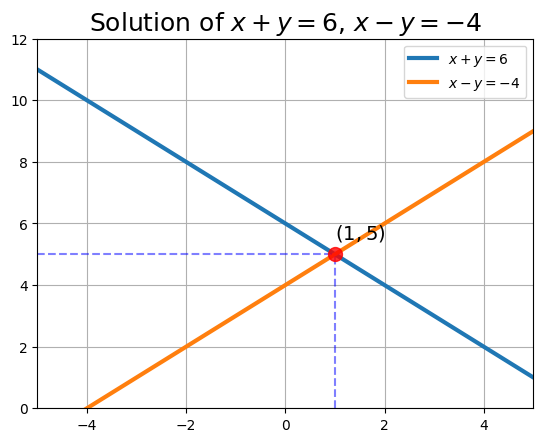

In [ ]:
x = np.linspace(-5, 5, 100)
y1 = -x + 6
y2 = x + 4

fig, ax = plt.subplots()
ax.scatter(1, 5, s = 100, zorder=5, color = 'r', alpha = .8)

ax.plot(x, y1, lw =3, label = '$x+y=6$')
ax.plot(x, y2, lw =3, label = '$x-y=-4$')
ax.plot([1, 1], [0, 5], ls = '--', color = 'b', alpha = .5)
ax.plot([-5, 1], [5, 5], ls = '--', color = 'b', alpha = .5)
ax.set_xlim([-5, 5]); ax.set_ylim([0, 12])

ax.legend()
s = '$(1,5)$'
ax.text(1, 5.5, s, fontsize =14)
ax.set_title('Solution of $x+y=6$, $x-y=-4$', size = 18)
ax.grid()

## Matrix Equation Form

다음 연립방정식을 행렬 형태로 표현한다.

$$
AX = B
$$

$$
A =
\begin{pmatrix}
1 & 1 \\
1 & -1
\end{pmatrix}, \quad
X =
\begin{pmatrix}
x \\
y
\end{pmatrix}, \quad
B =
\begin{pmatrix}
6 \\
-4
\end{pmatrix}
$$

---

## Step 1: Inverse of A

행렬식:

$$
\det(A) = (1 \times -1) - (1 \times 1) = -2
$$

역행렬:

$$
A^{-1} = \frac{1}{-2}
\begin{pmatrix}
-1 & -1 \\
-1 & 1
\end{pmatrix}
=
\begin{pmatrix}
0.5 & 0.5 \\
0.5 & -0.5
\end{pmatrix}
$$

---

## Step 2: Compute X

$$
X = A^{-1} B
$$

$$
\begin{pmatrix}
x \\
y
\end{pmatrix}
=
\begin{pmatrix}
0.5 & 0.5 \\
0.5 & -0.5
\end{pmatrix}
\begin{pmatrix}
6 \\
-4
\end{pmatrix}
$$

---

## Step 3: Solution

$$
x = 0.5 \times 6 + 0.5 \times (-4) = 1
$$

$$
y = 0.5 \times 6 + (-0.5) \times (-4) = 5
$$

---

## Final Answer

$$
\begin{pmatrix}
x \\
y
\end{pmatrix}
=
\begin{pmatrix}
1 \\
5
\end{pmatrix}
$$

# <font face="gotham" color="purple"> How to Draw a Plane </font>

Before drawing a plane, let's refresh the logic of Matplotlib 3D plotting. This should be familiar to you if you are a MATLAB user.

First, create meshgrids.

In [ ]:
x, y = [-1, 0, 1], [-1, 0, 1]
X, Y = np.meshgrid(x, y)

In [ ]:
X

array([[-1,  0,  1],
       [-1,  0,  1],
       [-1,  0,  1]])

In [ ]:
Y

array([[-1, -1, -1],
       [ 0,  0,  0],
       [ 1,  1,  1]])

Mathematically, meshgrids are the coordinates of _Cartesian products_. To illustrate, we can plot all the coordinates of these meshgrids

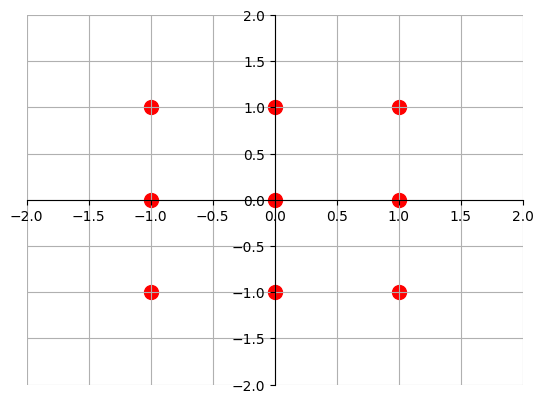

In [ ]:
fig, ax = plt.subplots()
ax.scatter(X, Y, s = 100, color = 'red')
ax.axis([-2, 2.0, -2.0, 2.0])
ax.spines['left'].set_position('zero') # alternative position is 'center'
ax.spines['right'].set_color('none')
ax.spines['bottom'].set_position('zero')
ax.spines['top'].set_color('none')
ax.grid()
plt.show()

Try a more complicated meshgrid.

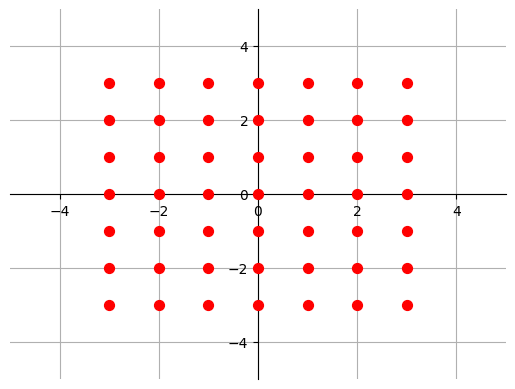

In [ ]:
x, y = np.arange(-3, 4, 1), np.arange(-3, 4, 1)
X, Y = np.meshgrid(x, y)

fig, ax = plt.subplots()
ax.scatter(X, Y, s = 50, color = 'red', zorder = 3)
ax.axis([-5, 5, -5, 5])

ax.spines['left'].set_position('zero') # alternative position is 'center'
ax.spines['right'].set_color('none')
ax.spines['bottom'].set_position('zero')
ax.spines['top'].set_color('none')
ax.grid()

Now consider the function $z = f(x, y)$, $z$ is in the $3rd$ dimension. Though Matplotlib is not meant for delicate plotting of 3D graphics, basic 3D plotting is still acceptable.

For example, we define a simple plane as
$$z= x + y$$
Then plot $z$

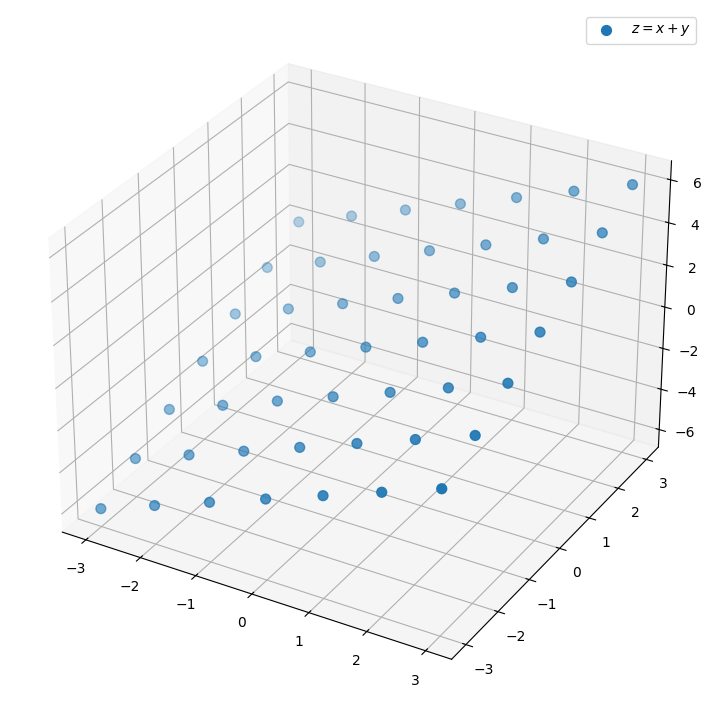

In [ ]:
Z = X + Y
fig = plt.figure(figsize = (9,9))
ax = fig.add_subplot(111, projection = '3d')
ax.scatter(X, Y, Z, s = 50, label = '$z=x+y$')
ax.legend()
plt.show()

Or we can plot it as a surface, Matplotlib will automatically interpolate values among the Cartesian coordinates such that the graph will look like a surface.

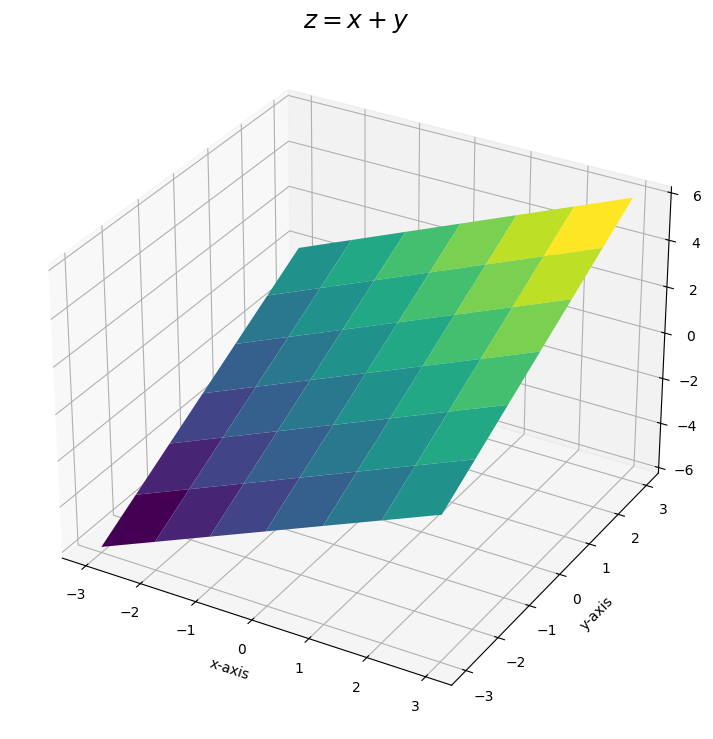

In [ ]:
fig = plt.figure(figsize = (9, 9))
ax = fig.add_subplot(111, projection = '3d')
ax.plot_surface(X, Y, Z, cmap ='viridis') # MATLAB default color map
ax.set_xlabel('x-axis')
ax.set_ylabel('y-axis')
ax.set_zlabel('z-axis')
ax.set_title('$z=x+y$', size = 18)
plt.show()

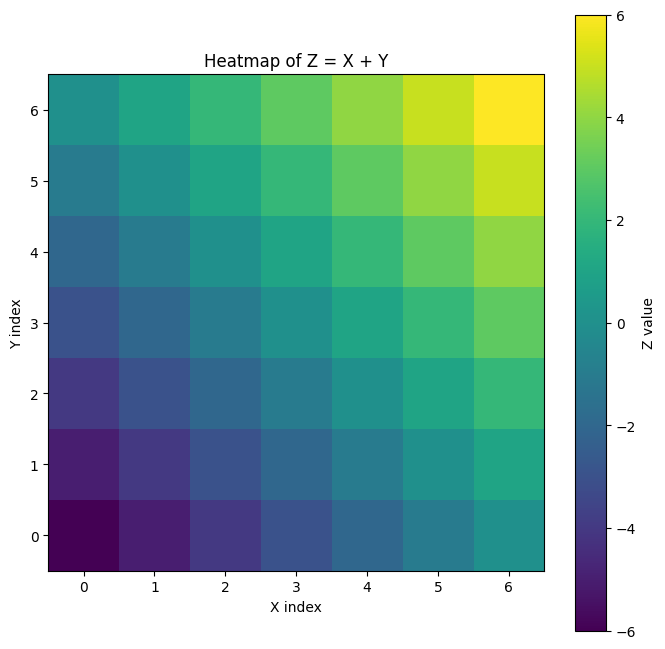

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
heatmap = ax.imshow(Z, cmap='viridis', origin='lower')
plt.colorbar(heatmap, ax=ax, label='Z value')
ax.set_title('Heatmap of Z = X + Y')
ax.set_xlabel('X index')
ax.set_ylabel('Y index')
plt.show()

In [ ]:
X

array([[-3, -2, -1,  0,  1,  2,  3],
       [-3, -2, -1,  0,  1,  2,  3],
       [-3, -2, -1,  0,  1,  2,  3],
       [-3, -2, -1,  0,  1,  2,  3],
       [-3, -2, -1,  0,  1,  2,  3],
       [-3, -2, -1,  0,  1,  2,  3],
       [-3, -2, -1,  0,  1,  2,  3]])

In [ ]:
Y

array([[-3, -3, -3, -3, -3, -3, -3],
       [-2, -2, -2, -2, -2, -2, -2],
       [-1, -1, -1, -1, -1, -1, -1],
       [ 0,  0,  0,  0,  0,  0,  0],
       [ 1,  1,  1,  1,  1,  1,  1],
       [ 2,  2,  2,  2,  2,  2,  2],
       [ 3,  3,  3,  3,  3,  3,  3]])

In [ ]:
Z

array([[-6, -5, -4, -3, -2, -1,  0],
       [-5, -4, -3, -2, -1,  0,  1],
       [-4, -3, -2, -1,  0,  1,  2],
       [-3, -2, -1,  0,  1,  2,  3],
       [-2, -1,  0,  1,  2,  3,  4],
       [-1,  0,  1,  2,  3,  4,  5],
       [ 0,  1,  2,  3,  4,  5,  6]])

# <font face="gotham" color="purple"> Visualisation of A System of Three Linear Equations  </font>

We have reviewed on plotting planes, now we are ready to plot several planes all together.

Consider this system of linear equations
\begin{align}
x_1- 2x_2+x_3&=0\\
2x_2-8x_3&=8\\
-4x_1+5x_2+9x_3&=-9
\end{align}
And solution is $(x_1, x_2, x_3)^T = (29, 16, 3)^T$. Let's reproduce the system visually.

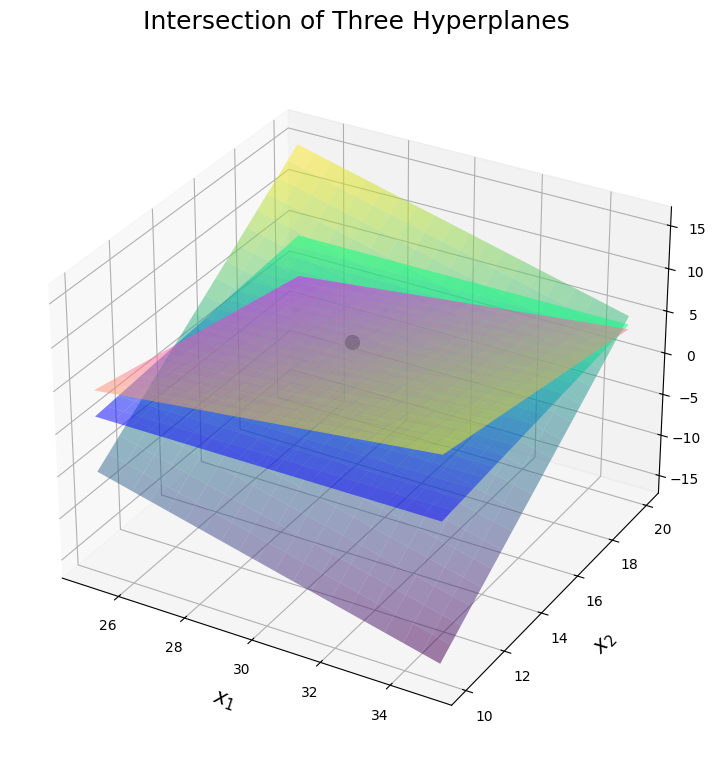

In [ ]:
x1 = np.linspace(25, 35, 20)
x2 = np.linspace(10, 20, 20)
X1, X2 = np.meshgrid(x1, x2)

fig = plt.figure(figsize = (9, 9))
ax = fig.add_subplot(111, projection = '3d')

X3 = 2*X2 - X1
ax.plot_surface(X1, X2, X3, cmap ='viridis', alpha = 0.5)

X3 = .25*X2 - 1
ax.plot_surface(X1, X2, X3, cmap ='winter', alpha = 0.5)

X3 = -5/9*X2 + 4/9*X1 - 1
ax.plot_surface(X1, X2, X3, cmap ='spring', alpha = 0.5)

ax.scatter(29, 16, 3, s = 100, color = 'black')  # 3개의 초평면의 교집합(교차점)

# 축 라벨 설정
ax.set_xlabel('$x_1$', size=15, labelpad=10)
ax.set_ylabel('$x_2$', size=15, labelpad=10)
ax.set_zlabel('$x_3$', size=15, labelpad=10)

# 그래프 제목 (선택 사항)
ax.set_title('Intersection of Three Hyperplanes', size=18, pad=20)

plt.show()

## **Task**
$AX = b$ 꼴로 만들고 해를 구하라:

$$A = \begin{pmatrix} 1 & -2 & 1 \\ 0 & 2 & -8 \\ -4 & 5 & 9 \end{pmatrix},
b = \begin{pmatrix} 0 \\ 8 \\ -9 \end{pmatrix}$$

We are certain there is a solution, however the graph does not show the intersection of planes. The problem originates from Matplotlib's rendering algorithm, which is not designed for drawing genuine 3D graphics. It merely projects 3D objects onto 2D dimension to imitate 3D features.



## <font face="gotham" color="purple"> Visualisation of A System With Infinite Numbers of Solutions </font>

Our system of equations is given

\begin{align}
y-z=&4\\
2x+y+2z=&4\\
2x+2y+z=&8
\end{align}

Rearrange to solve for $z$

\begin{align}
z=&y-4\\
z=&2-x-\frac{y}{2}\\
z=&8-2x-2y
\end{align}

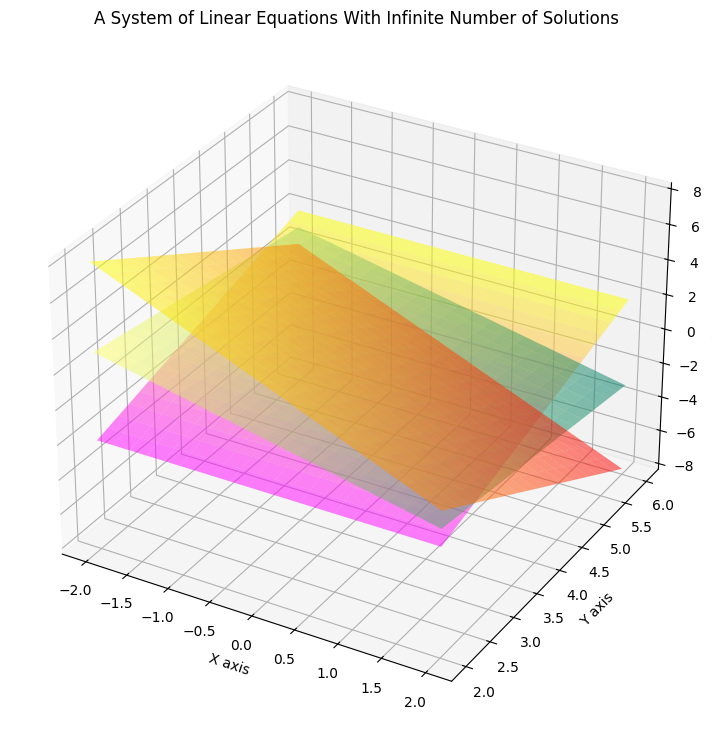

In [ ]:

# Create the figure and a 3D axis
fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111, projection='3d')

# Create the grid
X, Y = np.mgrid[-2:2:21j, 2:6:21j]

# Plot the first plane
Z1 = Y - 4
ax.plot_surface(X, Y, Z1, cmap='spring', alpha=0.5)

# Plot the second plane
Z2 = 2 - X - Y/2
ax.plot_surface(X, Y, Z2, cmap='summer', alpha=0.5)

# Plot the third plane
Z3 = 8 - 2*X - 2*Y
ax.plot_surface(X, Y, Z3, cmap='autumn', alpha=0.5)


# Add axes labels
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Z axis')

# Add title
plt.title('A System of Linear Equations With Infinite Number of Solutions')

# Show the plot
plt.show()

The solution of the system is $(x,y,z)=(-3z/2,z+4,z)^T$, where $z$ is a **free variable**.

The solution is an infinite line in $\mathbb{R}^3$, to visualise the solution requires setting a range of $x$ and $y$, for instance we can set

\begin{align}
-2 \leq x \leq 2\\
2 \leq y \leq 6
\end{align}

which means

\begin{align}
-2\leq -\frac32z\leq 2\\
2\leq z+4 \leq 6
\end{align}

We can pick one inequality to set the range of $z$, e.g. second inequality: $-2 \leq z \leq 2$.

Then plot the planes and the solutions together.

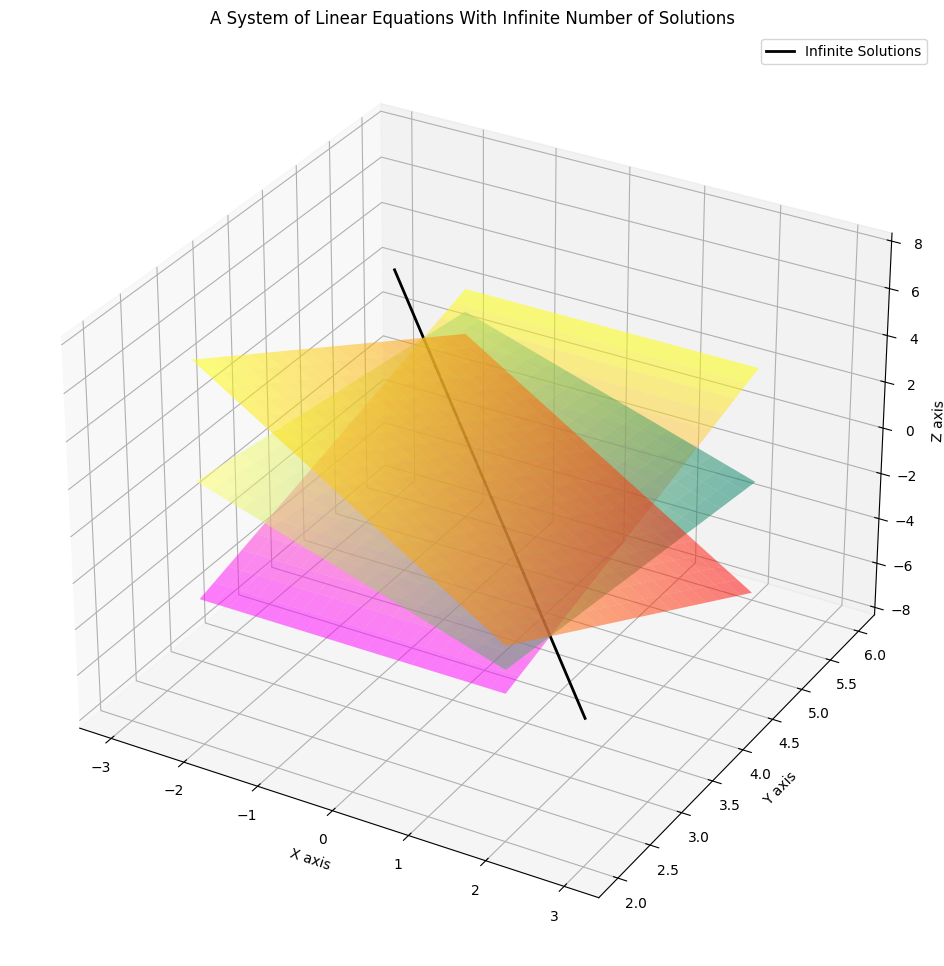

In [ ]:

# Create the figure and a 3D axis
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='3d')

# Create the grid
X, Y = np.mgrid[-2:2:21j, 2:6:21j]

# Plot the first plane
Z1 = Y - 4
ax.plot_surface(X, Y, Z1, cmap='spring', alpha=0.5)

# Plot the second plane
Z2 = 2 - X - Y / 2
ax.plot_surface(X, Y, Z2, cmap='summer', alpha=0.5)

# Plot the third plane
Z3 = 8 - 2 * X - 2 * Y
ax.plot_surface(X, Y, Z3, cmap='autumn', alpha=0.5)

# Define the line of infinite solutions
ZL = np.linspace(-2, 2, 20)  # ZL means Z for line, chosen range [-2, 2]
XL = -3 * ZL / 2
YL = ZL + 4

# Plot the line
ax.plot(XL, YL, ZL, color='black', linewidth=2, label='Infinite Solutions')

# Add axes labels
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Z axis')

# Add title and legend
plt.title('A System of Linear Equations With Infinite Number of Solutions')
ax.legend()

# Show the plot
plt.show()